In [41]:
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from fontTools.misc.cython import returns
from lightfm import LightFM
from sklearn.model_selection import train_test_split
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import seaborn as sns

import os


In [42]:
DATASET_PATH = r'C:\Users\Egor\Desktop\study\diploma\project\dataset'
RESULT_PREPROCESSED_PATH = r'C:\Users\Egor\Desktop\study\diploma\project\dataset_preprocessed'
os.makedirs(RESULT_PREPROCESSED_PATH, exist_ok=True)


In [43]:

def reduce_mem_usage(df):
    numerics = ['int16', 'int32', 'int64', 'float16', 'float32', 'float64']
    start_mem = df.memory_usage().sum() / 1024 ** 2
    for col in df.columns:
        col_type = df[col].dtypes
        if col_type in numerics:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                else:
                    df[col] = df[col].astype(np.int64)
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
    end_mem = df.memory_usage().sum() / 1024 ** 2
    print(f'Memory: {start_mem:.2f} Mb -> {end_mem:.2f} Mb ({100 * (start_mem - end_mem) / start_mem:.1f}% reduction)')
    return df


def load_data(data_dir):
    print("Загрузка данных...")
    transactions = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "transactions_train.csv")))
    articles = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "articles.csv")))
    customers = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "customers.csv")))
    sample_sub = reduce_mem_usage(pd.read_csv(os.path.join(data_dir, "sample_submission.csv")))
    return transactions, articles, customers, sample_sub


In [44]:
transactions, articles, customers, sample_sub = load_data(DATASET_PATH)

Загрузка данных...
Memory: 1212.63 Mb -> 697.26 Mb (42.5% reduction)
Memory: 20.13 Mb -> 13.59 Mb (32.5% reduction)
Memory: 73.27 Mb -> 49.72 Mb (32.1% reduction)
Memory: 20.93 Mb -> 20.93 Mb (0.0% reduction)


In [45]:
print("Пропуски в articles:")
print(articles.isnull().sum())

print("Пропуски в customers:")
print(customers.isnull().sum())

print("Пропуски в transactions:")
print(transactions.isnull().sum())


Пропуски в articles:
article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64
Пропуски в customers:
customer_id                    0
FN         

In [46]:
for col in ['detail_desc']:
    if col in articles.columns:
        articles[col] = articles[col].fillna("Unknown")

customers['FN'] = customers['FN'].fillna(0).astype(int)
customers['postal_code'] = customers['postal_code'].fillna(customers['postal_code'].mode()[0])
customers['age'] = customers['age'].fillna(customers['age'].median()).astype(int)
active_mode = 0
customers['Active'] = customers['Active'].fillna(active_mode).astype(int)
customers['club_member_status'] = customers['club_member_status'].fillna('UNKNOWN')
customers['fashion_news_frequency'] = customers['fashion_news_frequency'].fillna('NONE')

In [47]:
transactions['t_dat'] = pd.to_datetime(transactions['t_dat'])
customers['age'] = customers['age'].astype(int)
transactions = transactions.drop_duplicates()
articles = articles.drop_duplicates(subset=['article_id'])
customers = customers.drop_duplicates(subset=['customer_id'])

In [48]:
print("После очистки:")
print(f"transactions: {transactions.shape}")
print(f"articles: {articles.shape}")
print(f"customers: {customers.shape}")

После очистки:
transactions: (28805603, 5)
articles: (105542, 25)
customers: (1371980, 7)


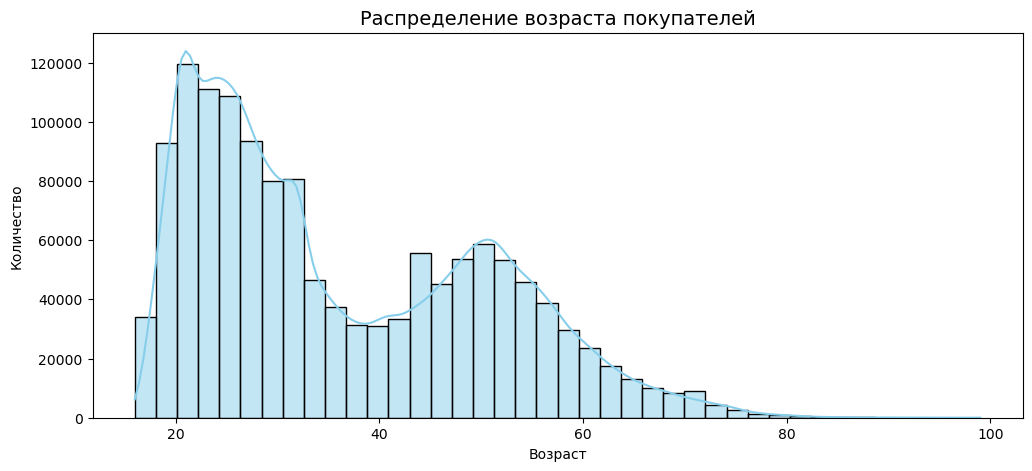

In [49]:
plt.figure(figsize=(12, 5))
sns.histplot(customers['age'], bins=40, kde=True, color='skyblue')
plt.title('Распределение возраста покупателей', fontsize=14)
plt.xlabel('Возраст')
plt.ylabel('Количество')
plt.show()

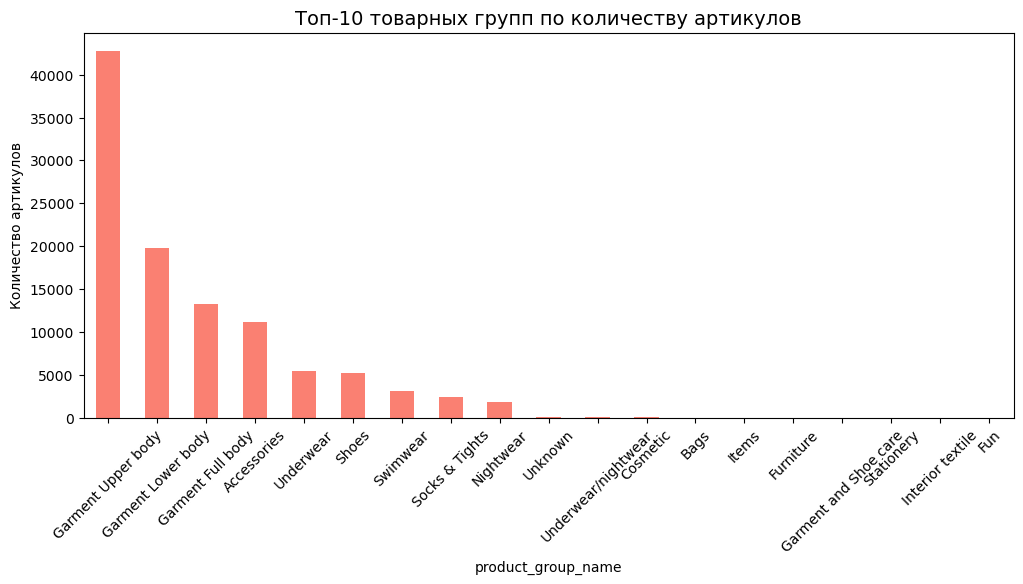

In [50]:
group_counts = articles['product_group_name'].value_counts()
plt.figure(figsize=(12, 5))
group_counts.plot(kind='bar', color='salmon')
plt.title('Топ-10 товарных групп по количеству артикулов', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Количество артикулов')
plt.show()

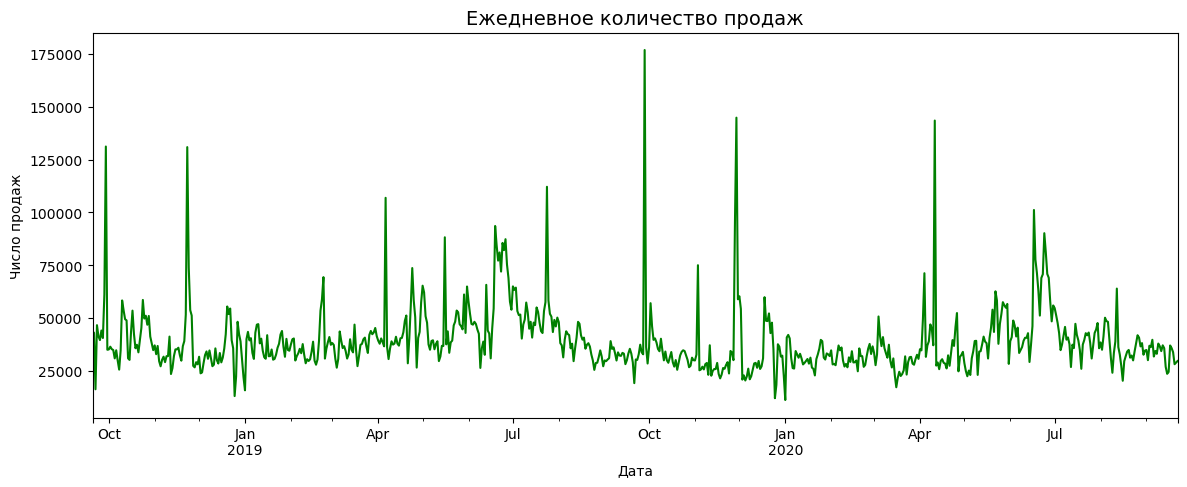

In [51]:
daily_sales = transactions.groupby('t_dat').size()
plt.figure(figsize=(14, 5))
daily_sales.plot(color='green')
plt.title('Ежедневное количество продаж', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Число продаж')
plt.show()

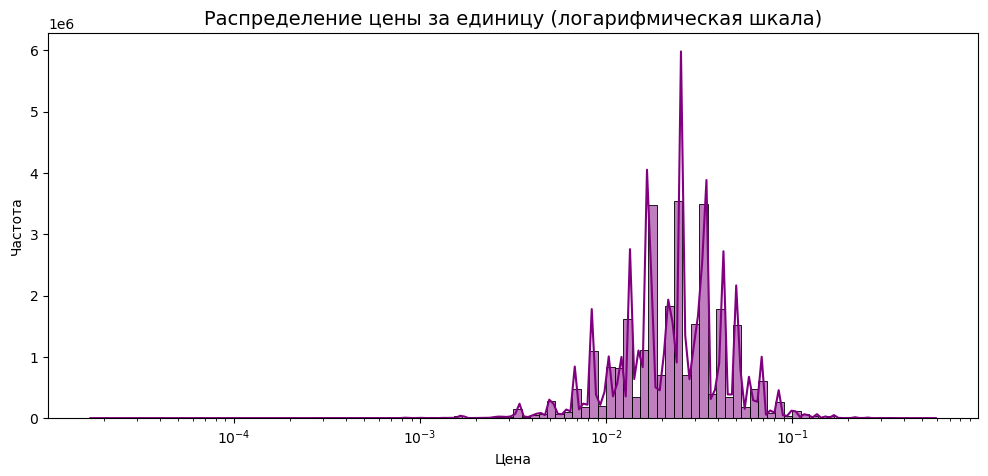

In [52]:
plt.figure(figsize=(12, 5))
sns.histplot(transactions['price'], bins=100, log_scale=True, kde=True, color='purple')
plt.title('Распределение цены за единицу (логарифмическая шкала)', fontsize=14)
plt.xlabel('Цена')
plt.ylabel('Частота')
plt.show()

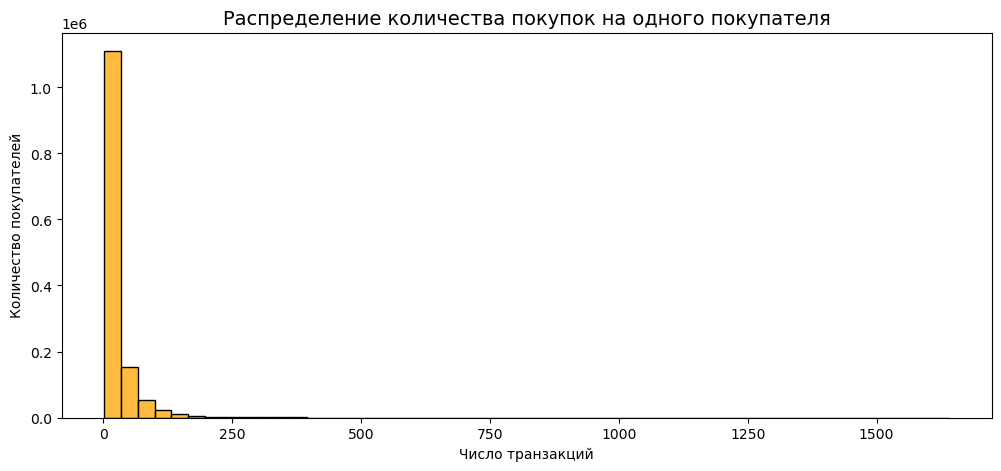

Среднее число покупок на клиента: 21.15
Медиана: 9.0
% клиентов с 1 покупкой: 10.9%


In [53]:
purchase_freq = transactions.groupby('customer_id').size()
plt.figure(figsize=(12, 5))
sns.histplot(purchase_freq, bins=50, log_scale=False, color='orange')
plt.title('Распределение количества покупок на одного покупателя', fontsize=14)
plt.xlabel('Число транзакций')
plt.ylabel('Количество покупателей')
plt.show()
print(f"Среднее число покупок на клиента: {purchase_freq.mean():.2f}")
print(f"Медиана: {purchase_freq.median()}")
print(f"% клиентов с 1 покупкой: { (purchase_freq == 1).mean() * 100:.1f}%")

In [54]:
### Добавление признаков

In [55]:
transactions['year'] = transactions['t_dat'].dt.year
transactions['month'] = transactions['t_dat'].dt.month
transactions['day_of_week'] = transactions['t_dat'].dt.dayofweek
transactions['weekend'] = (transactions['day_of_week'] >= 5).astype(int)
transactions['season'] = transactions['month'].map({12:0,1:0,2:0, 3:1,4:1,5:1, 6:2,7:2,8:2, 9:3,10:3,11:3})  # 0-winter,1-spring,2-summer,3-autumn

In [56]:
max_date = transactions['t_dat'].max()

rfm = transactions.groupby('customer_id').agg({
    't_dat': lambda x: (max_date - x.max()).days,  # Recency
    'customer_id': 'count',                        # Frequency
    'price': 'sum'                                 # Monetary
}).rename(columns={'t_dat': 'recency', 'customer_id': 'frequency', 'price': 'monetary'})
rfm['avg_basket'] = rfm['monetary'] / rfm['frequency']


In [57]:
print(transactions.groupby('article_id')['price'].mean().head())
print(articles.head())
article_popularity = transactions.groupby('article_id').size().rename('article_popularity')
article_avg_price = transactions.groupby('article_id')['price'].mean().rename('article_avg_sold_price')
articles = articles.merge(article_popularity, on='article_id', how='left')
articles = articles.merge(article_avg_price, on='article_id', how='left')
articles['article_popularity'] = articles['article_popularity'].fillna(0)
articles['article_avg_sold_price'] = articles['article_avg_sold_price'].fillna(transactions['price'].median())

article_id
108775015    0.008112
108775044    0.008096
108775051    0.004980
110065001    0.020055
110065002    0.018087
Name: price, dtype: float32
   article_id  product_code          prod_name  product_type_no  \
0   108775015        108775          Strap top              253   
1   108775044        108775          Strap top              253   
2   108775051        108775      Strap top (1)              253   
3   110065001        110065  OP T-shirt (Idro)              306   
4   110065002        110065  OP T-shirt (Idro)              306   

  product_type_name  product_group_name  graphical_appearance_no  \
0          Vest top  Garment Upper body                  1010016   
1          Vest top  Garment Upper body                  1010016   
2          Vest top  Garment Upper body                  1010017   
3               Bra           Underwear                  1010016   
4               Bra           Underwear                  1010016   

  graphical_appearance_name  colour_gro

In [58]:
customers['age_group'] = pd.cut(customers['age'], bins=[0, 20, 30, 40, 50, 60, 100], labels=['<20', '20-29', '30-39', '40-49', '50-59', '60+'])


In [59]:
weekend_ratio = transactions.groupby('customer_id')['weekend'].mean().rename('weekend_purchase_ratio')
rfm = rfm.join(weekend_ratio, how='left').fillna(0)

In [60]:
trans_w_group = transactions.merge(articles[['article_id', 'product_group_name']], on='article_id', how='left')
top_group_per_cust = trans_w_group.groupby('customer_id')['product_group_name'].agg(lambda x: x.mode()[0] if len(x.mode())>0 else 'Unknown').rename('fav_product_group')
rfm = rfm.join(top_group_per_cust, how='left')

In [61]:
unique_articles = transactions.groupby('customer_id')['article_id'].nunique().rename('n_unique_articles')
rfm = rfm.join(unique_articles, how='left').fillna(0)

print("RFM таблица сформирована, shape:", rfm.shape)
print(rfm.head())

RFM таблица сформирована, shape: (1362281, 7)
                                                    recency  frequency  \
customer_id                                                              
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d...       17         19   
0000423b00ade91418cceaf3b26c6af3dd342b51fd051ee...       76         78   
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad...        7         15   
00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c...      471          2   
00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe...       41         13   

                                                    monetary  avg_basket  \
customer_id                                                                
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d...  0.543953    0.028629   
0000423b00ade91418cceaf3b26c6af3dd342b51fd051ee...  2.412540    0.030930   
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad...  0.606590    0.040439   
00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c...  0.0

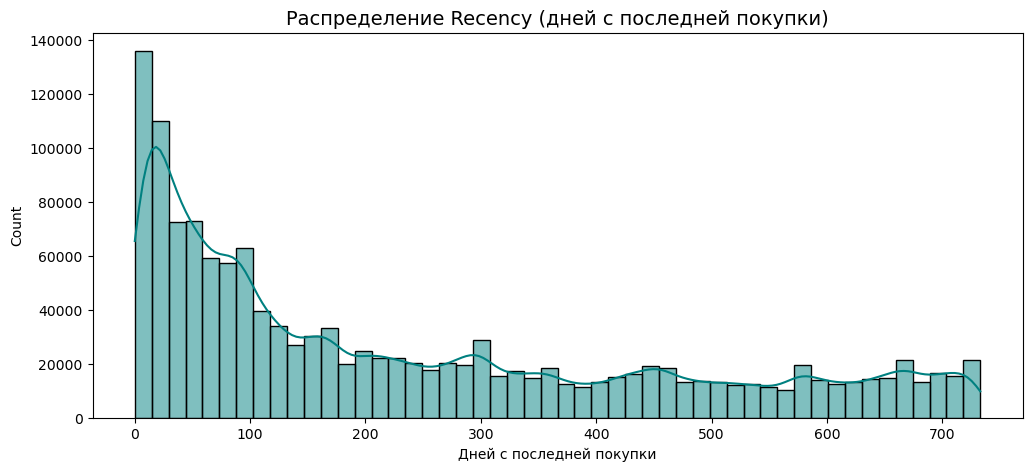

C:\Users\Egor\anaconda3\envs\torch\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


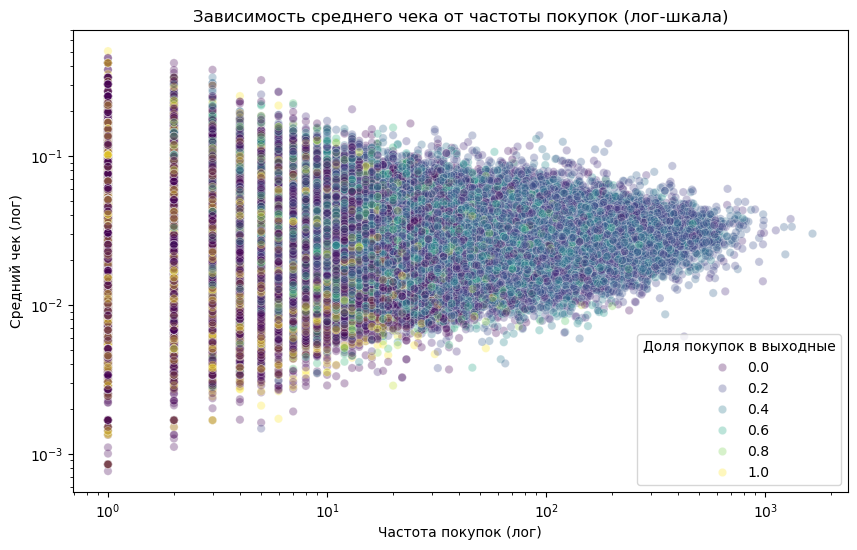

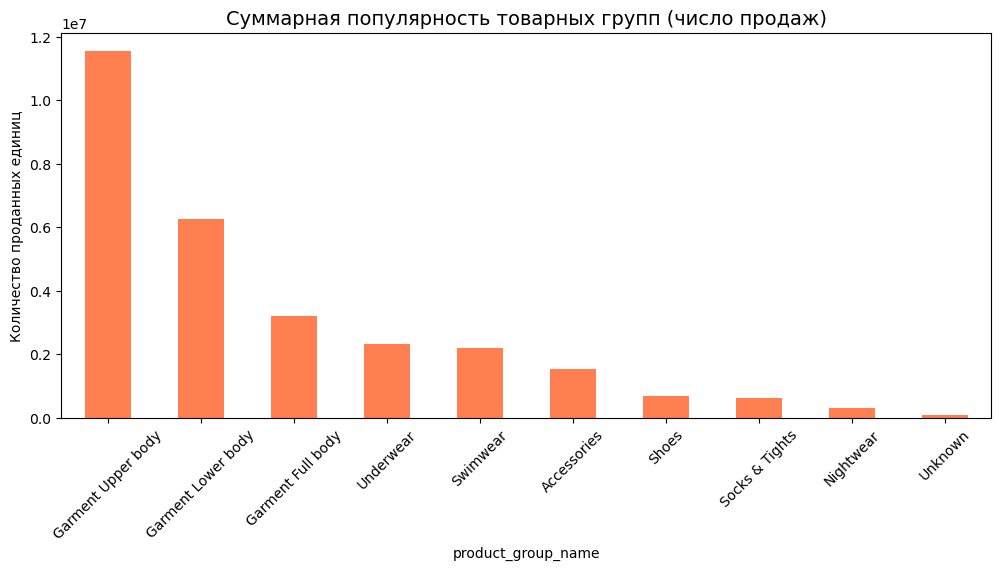

In [62]:
# График 6: Распределение recency
plt.figure(figsize=(12, 5))
sns.histplot(rfm['recency'], bins=50, kde=True, color='teal')
plt.title('Распределение Recency (дней с последней покупки)', fontsize=14)
plt.xlabel('Дней с последней покупки')
plt.show()

# График 7: Средний чек vs частота
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rfm, x='frequency', y='avg_basket', alpha=0.3, hue='weekend_purchase_ratio', palette='viridis')
plt.xscale('log')
plt.yscale('log')
plt.title('Зависимость среднего чека от частоты покупок (лог-шкала)')
plt.xlabel('Частота покупок (лог)')
plt.ylabel('Средний чек (лог)')
plt.legend(title='Доля покупок в выходные')
plt.show()

# График 8: Популярность товарных групп (агрегированная)
top_products = articles.groupby('product_group_name')['article_popularity'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,5))
top_products.plot(kind='bar', color='coral')
plt.title('Суммарная популярность товарных групп (число продаж)', fontsize=14)
plt.xticks(rotation=45)
plt.ylabel('Количество проданных единиц')
plt.show()


In [63]:
articles.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "articles.csv"), index=False)
customers.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "customers.csv"), index=False)
transactions.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "transactions.csv"), index=False)
rfm.to_csv(os.path.join(RESULT_PREPROCESSED_PATH, "rfm_features.csv"))
print("Все файлы сохранены.")

Все файлы сохранены.
